# Part 2a.

In [4]:
import math
import ROOT
import datetime

def smear_muons(signal_file, out_file):
    og_signal_file = ROOT.TFile(signal_file)

    og_signal_tree = og_signal_file.Get("Events")

    smeared_file = ROOT.TFile(out_file, "RECREATE")
    smeared_tree = ROOT.TTree("Events", "Muon tree with Gaussian smearing")

    mu_pt_s  = ROOT.std.vector('float')()
    mu_theta_s = ROOT.std.vector('float')()
    mu_eta_s = ROOT.std.vector('float')()
    mu_phi_s = ROOT.std.vector('float')()
    mu_q_s = ROOT.std.vector('int')()

    pi_pt_s = ROOT.std.vector('float')()
    pi_eta_s = ROOT.std.vector('float')()
    pi_phi_s = ROOT.std.vector('float')()
    pi_q_s = ROOT.std.vector('int')()

    smeared_tree.Branch("mu_pt_s",  mu_pt_s)
    smeared_tree.Branch("mu_theta_s", mu_theta_s)
    smeared_tree.Branch("mu_eta_s", mu_eta_s)
    smeared_tree.Branch("mu_phi_s", mu_phi_s)
    smeared_tree.Branch("mu_q_s", mu_q_s)

    smeared_tree.Branch("pi_pt_s", pi_pt_s)
    smeared_tree.Branch("pi_eta_s", pi_eta_s)
    smeared_tree.Branch("pi_phi_s", pi_phi_s)
    smeared_tree.Branch("pi_q_s", pi_q_s)

    date_time=datetime.datetime.now()
    time_seed=date_time.time().strftime('%H%M%S')

    rng = ROOT.TRandom3(int(time_seed))

    for event in og_signal_tree:

        mu_pt_s.clear(); mu_theta_s.clear(); mu_eta_s.clear(); mu_phi_s.clear(); mu_q_s.clear()
        pi_pt_s.clear(); pi_eta_s.clear(); pi_phi_s.clear(); pi_q_s.clear()

        for i in range(event.mu_pt.size()):
            pt  = event.mu_pt[i]
            eta = event.mu_eta[i]
            theta = 2*math.atan(math.exp(-eta))
            phi = event.mu_phi[i]
            q = event.mu_q[i]

            # smearing
            pt_s  = rng.Gaus(pt, 0.01 * pt)
            theta_s = rng.Gaus(theta, 0.002)
            phi_s = rng.Gaus(phi, 0.002)

            mu_pt_s.push_back(pt_s)
            mu_theta_s.push_back(theta_s)
            mu_eta_s.push_back(eta)
            mu_phi_s.push_back(phi_s)
            mu_q_s.push_back(q)
    
        for j in range(event.pi_pt.size()):

            pt_pi = event.pi_pt[j]
            eta_pi = event.pi_eta[j]
            phi_pi = event.pi_phi[j]
            q_pi = event.pi_q[j]


            pi_pt_s.push_back(pt_pi)
            pi_eta_s.push_back(eta_pi)
            pi_phi_s.push_back(phi_pi)
            pi_q_s.push_back(q_pi)

        smeared_tree.Fill()

    smeared_file.Write()

    canvas1 = ROOT.TCanvas("c1", "Canvas1", 800, 600)
    og_signal_tree.Draw("mu_pt>>h1(50,0,200)")
    h1 = ROOT.gDirectory.Get("h1")
    h1.SetLineColor(ROOT.kBlue)
    h1.SetLineWidth(2)

    smeared_tree.Draw("mu_pt_s>>h2(50,0,200)")
    h2 = ROOT.gDirectory.Get("h2")
    h2.SetLineColor(ROOT.kRed)
    h2.SetLineWidth(2)

    # Draw together
    h1.Draw("HIST")
    h2.Draw("HIST SAME")

    legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
    legend.AddEntry(h1, "Muon pT", "l")
    legend.AddEntry(h2, "Smeared muon pT", "l")
    legend.Draw()

    canvas1.Update()
    canvas1.Print("pt_smearing.png")    

    canvas2 = ROOT.TCanvas("c2", "Canvas2", 800, 600)
    og_signal_tree.Draw(f"mu_phi>>hphi(50,{-math.pi},{math.pi})")
    hphi = ROOT.gDirectory.Get("hphi")
    hphi.SetLineColor(ROOT.kBlue)
    hphi.SetLineWidth(2)

    smeared_tree.Draw(f"mu_phi_s>>hphi2(50,{-math.pi},{math.pi})")
    hphi2 = ROOT.gDirectory.Get("hphi2")
    hphi2.SetLineColor(ROOT.kRed)
    hphi2.SetLineWidth(2)

    hphi.Draw("HIST")
    hphi2.Draw("HIST SAME")

    legend = ROOT.TLegend(0.1, 0.7, 0.3, 0.9)
    legend.AddEntry(hphi, "Muon phi", "l")
    legend.AddEntry(hphi2, "Smeared muon phi", "l")
    legend.Draw()

    canvas2.Update()
    canvas2.Print("phi_smearing.png")

    canvas3 = ROOT.TCanvas("c3", "Canvas3", 800, 600)
    og_signal_tree.Draw(f"2*atan(exp(-mu_eta))>>htheta(50,0,{math.pi})")
    htheta = ROOT.gDirectory.Get("htheta")
    htheta.SetLineColor(ROOT.kBlue)
    htheta.SetLineWidth(2)

    smeared_tree.Draw(f"mu_theta_s>>htheta2(50,0,{math.pi})")
    htheta2 = ROOT.gDirectory.Get("htheta2")
    htheta2.SetLineColor(ROOT.kRed)
    htheta2.SetLineWidth(2)
    
    htheta.Draw("HIST")
    htheta2.Draw("HIST SAME")

    legend = ROOT.TLegend(0.4, 0.7, 0.6, 0.9)
    legend.AddEntry(htheta, "Muon theta", "l")
    legend.AddEntry(htheta2, "Smeared muon theta", "l")
    legend.Draw()

    canvas3.Update()
    canvas3.Print("theta_smearing.png")

    smeared_file.Close() 
    og_signal_file.Close()


smear_muons("signal.root", "signal_smeared-106.root")
smear_muons("background.root", "background_smeared-106.root")

Info in <TCanvas::Print>: png file pt_smearing.png has been created
Info in <TCanvas::Print>: png file phi_smearing.png has been created
Info in <TCanvas::Print>: png file theta_smearing.png has been created
Info in <TCanvas::Print>: png file pt_smearing.png has been created
Info in <TCanvas::Print>: png file phi_smearing.png has been created
Info in <TCanvas::Print>: png file theta_smearing.png has been created


# Part 2b.

In [5]:
MUON_MASS_GEV = 0.10566
PION_MASS_GEV = 0.139
LUMI_FB = 110.0

def read_meta(root_file_path):

    f = ROOT.TFile(root_file_path)
    meta = f.Get("Meta")
    meta.GetEntry(0)
    n_total  = int(meta.Ntotal)
    sigma_fb = float(meta.SigmaFb)
    f.Close()
    return n_total, sigma_fb


def build_lorentz(pt_s, theta_s, phi_s):
    
    eta_s = -math.log(math.tan(theta_s / 2.0))
    vec   = ROOT.TLorentzVector()
    vec.SetPtEtaPhiM(pt_s, eta_s, phi_s, MUON_MASS_GEV)
    return vec

In [6]:
def fill_m4mu(smeared_file, meta_file, hist, lumi_fb):
  
    n_total, sigma_fb = read_meta(meta_file)
    event_weight = sigma_fb * lumi_fb / n_total

    print(f"  File        : {smeared_file}")
    print(f"  sigma_gen   : {sigma_fb:.4g} fb")
    print(f"  N_total     : {n_total}")
    print(f"  Event weight: {event_weight:.4e} (expected events per generated event)")

    f    = ROOT.TFile(smeared_file)
    tree = f.Get("Events")

    n_pass = 0

    for i in range(tree.GetEntries()):
        tree.GetEntry(i)

        selected_muons = []  

        for i_mu in range(tree.mu_pt_s.size()):
            pt_s    = tree.mu_pt_s[i_mu]
            theta_s = tree.mu_theta_s[i_mu]
            phi_s   = tree.mu_phi_s[i_mu]

            if pt_s >= 30.0:
                continue

            theta_s = max(1e-6, min(math.pi - 1e-6, theta_s))
            eta_s   = -math.log(math.tan(theta_s / 2.0))
            iso_sum = 0.0
            for i_pi in range(tree.pi_pt_s.size()):

                mu_s = ROOT.TLorentzVector()
                pi_s = ROOT.TLorentzVector()

                mu_s.SetPtEtaPhiM(pt_s, eta_s, phi_s, MUON_MASS_GEV)
                pi_s.SetPtEtaPhiM(tree.pi_pt_s[i_pi], tree.pi_eta_s[i_pi], tree.pi_phi_s[i_pi], PION_MASS_GEV)

                dR = mu_s.DeltaR(pi_s)
                
                if dR < 0.3:
                    iso_sum += tree.pi_pt_s[i_pi]

            if iso_sum >= 1.5:
                continue

            selected_muons.append(build_lorentz(pt_s, theta_s, phi_s))

        if len(selected_muons) < 4:
            continue

        n_pass += 1

        four_vec = ROOT.TLorentzVector()
        for vec in selected_muons[:4]:
            four_vec += vec

        m4mu = four_vec.M()         
        hist.Fill(m4mu, event_weight)

    f.Close()
    print(f"  Events passing 2a selection: {n_pass}")
    print()

In [7]:

N_BINS = 50
M_LOW  = 50.0    
M_HIGH = 180.0   

h_sig = ROOT.TH1F("h_sig",
                  "Signal H#rightarrowZZ*#rightarrow4#mu",
                  N_BINS, M_LOW, M_HIGH)

h_bkg = ROOT.TH1F("h_bkg",
                  "Background ZZ/#gamma*#rightarrow4#mu",
                  N_BINS, M_LOW, M_HIGH)


In [8]:

print("Signal")
fill_m4mu("signal_smeared-106.root","signal.root",h_sig, LUMI_FB)

print("Background")
fill_m4mu("background_smeared-106.root","background.root", h_bkg, LUMI_FB)

Signal
  File        : signal_smeared-106.root
  sigma_gen   : 1.015 fb
  N_total     : 946937
  Event weight: 1.1794e-04 (expected events per generated event)
  Events passing 2a selection: 37640

Background
  File        : background_smeared-106.root
  sigma_gen   : 18.05 fb
  N_total     : 53062
  Event weight: 3.7410e-02 (expected events per generated event)
  Events passing 2a selection: 617



# Part 2c.

Plot saved to M4mu_signal_plus_background.png

Fitted Higgs mass : 124.24 GeV
Fitted width      : 4.00 GeV
Signal window     : [116.24, 132.24] GeV

Ns = 2.57
Nb = 1.64
Significance      : 2.01 sigma

Luminosity for 5σ : 678.7 fb⁻¹
At 326.03 fb⁻¹/year that takes ≈ 760 days (2.08 years) of CMS Run 3 data-taking
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      29.6935
NDf                       =           25
Edm                       =  3.57067e-06
NCalls                    =          388
p0                        =      7.92964   +/-   0.789429     	 (limited)
p1                        =      124.238   +/-   0.40594      	 (limited)
p2                        =      3.99994   +/-   1.50264      	 (limited)
p3                        =     -0.17756   +/-   0.345582    
p4                        =  -0.00924463   +/-   0.003021     	 (limited)


Info in <TCanvas::Print>: png file M4mu_signal_plus_background.png has been created


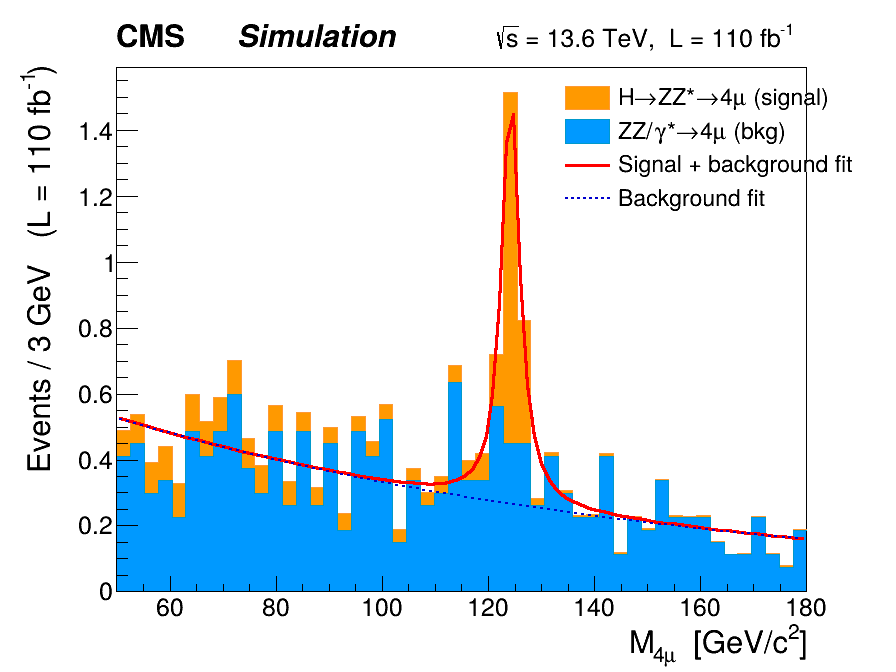

In [9]:
h_total = h_sig.Clone("h_total")
h_total.Add(h_bkg)

FIT_LOW  = 80.0
FIT_HIGH = 160.0

fit_func = ROOT.TF1(
    "fit_func",
    "[0]*TMath::BreitWigner(x,[1],[2]) + exp([3]+[4]*x)",
    FIT_LOW, FIT_HIGH
)

fit_func.SetParameter(0, 3.0)     # BW amplitude
fit_func.SetParameter(1, 125.0)   # Higgs mass
fit_func.SetParameter(2, 2.0)     # width
fit_func.SetParameter(3, 0.5)     # expo constant
fit_func.SetParameter(4, -0.01)   # expo slope

fit_func.SetParLimits(0, 0.0,   10.0)
fit_func.SetParLimits(1, 120.0, 130.0)
fit_func.SetParLimits(2, 1.0,   4.0)    
fit_func.SetParLimits(4, -1.0,  0.0)

h_total.Fit(fit_func, "RN")

# Signal+background display — full range
sig_bkg_display = ROOT.TF1(
    "sig_bkg_display",
    "[0]*TMath::BreitWigner(x,[1],[2]) + exp([3]+[4]*x)",
    M_LOW, M_HIGH
)
sig_bkg_display.SetParameters(*[fit_func.GetParameter(i) for i in range(5)])
sig_bkg_display.SetLineColor(ROOT.kRed)
sig_bkg_display.SetLineWidth(3)

# Background only — full range
bkg_func = ROOT.TF1("bkg_func", "exp([0]+[1]*x)", M_LOW, M_HIGH)
bkg_func.SetParameters(fit_func.GetParameter(3),
                        fit_func.GetParameter(4))
bkg_func.SetLineColor(ROOT.kBlue + 1)
bkg_func.SetLineWidth(2)
bkg_func.SetLineStyle(2)

# Signal only for significance integrals (not drawn)
sig_func = ROOT.TF1(
    "sig_func",
    "[0]*TMath::BreitWigner(x,[1],[2])",
    M_LOW, M_HIGH
)
sig_func.SetParameters(fit_func.GetParameter(0),
                        fit_func.GetParameter(1),
                        fit_func.GetParameter(2))

#Drawing 
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetOptTitle(0)
BIN_WIDTH = (M_HIGH - M_LOW) / N_BINS

h_bkg.SetFillColor(ROOT.kAzure + 7)
h_bkg.SetLineColor(ROOT.kAzure + 9)
h_bkg.SetLineWidth(1)
h_sig.SetFillColor(ROOT.kOrange - 3)
h_sig.SetLineColor(ROOT.kOrange + 1)
h_sig.SetLineWidth(1)

stack = ROOT.THStack("stack2", "")
stack.Add(h_bkg)
stack.Add(h_sig)

c = ROOT.TCanvas("c2", "M_{4#mu}", 900, 700)
c.SetLeftMargin(0.13)
c.SetBottomMargin(0.12)

stack.Draw("HIST")
sig_bkg_display.Draw("SAME")
bkg_func.Draw("SAME")

stack.GetXaxis().SetTitle("M_{4#mu}  [GeV/c^{2}]")
stack.GetYaxis().SetTitle(
    f"Events / {BIN_WIDTH:.0f} GeV   (L = {LUMI_FB:.0f} fb^{{-1}})")
stack.GetXaxis().SetTitleSize(0.05)
stack.GetYaxis().SetTitleSize(0.05)
stack.GetXaxis().SetLabelSize(0.04)
stack.GetYaxis().SetLabelSize(0.04)

leg = ROOT.TLegend(0.62, 0.68, 0.90, 0.88)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.038)
leg.AddEntry(h_sig,           "H#rightarrowZZ*#rightarrow4#mu (signal)", "f")
leg.AddEntry(h_bkg,           "ZZ/#gamma*#rightarrow4#mu (bkg)",         "f")
leg.AddEntry(sig_bkg_display, "Signal + background fit",                 "l")
leg.AddEntry(bkg_func,        "Background fit",                          "l")
leg.Draw()

lbl = ROOT.TLatex()
lbl.SetNDC()
lbl.SetTextFont(62)
lbl.SetTextSize(0.05)
lbl.DrawLatex(0.13, 0.93, "CMS  #it{Simulation}")
lbl.SetTextFont(42)
lbl.SetTextSize(0.04)
lbl.DrawLatex(0.55, 0.93,
              f"#sqrt{{s}} = 13.6 TeV,  L = {LUMI_FB:.0f} fb^{{-1}}")

c.Update()
c.Draw()
c.SaveAs("M4mu_signal_plus_background.png")
print("Plot saved to M4mu_signal_plus_background.png")

#Signal window & event counts 
mean  = fit_func.GetParameter(1)
sigma = fit_func.GetParameter(2)

window_low  = mean - 2 * sigma
window_high = mean + 2 * sigma

print(f"\nFitted Higgs mass : {mean:.2f} GeV")
print(f"Fitted width      : {sigma:.2f} GeV")
print(f"Signal window     : [{window_low:.2f}, {window_high:.2f}] GeV")

Ns = sig_func.Integral(window_low, window_high) / BIN_WIDTH
Nb = bkg_func.Integral(window_low, window_high) / BIN_WIDTH

print(f"\nNs = {Ns:.2f}")
print(f"Nb = {Nb:.2f}")

#Significance & luminosity projection 
significance = Ns / (Nb ** 0.5)
print(f"Significance      : {significance:.2f} sigma")

L_needed = LUMI_FB * (5.0 / significance) ** 2
print(f"\nLuminosity for 5σ : {L_needed:.1f} fb⁻¹")

run3_lumi_per_year = 326.03
time_years = L_needed / run3_lumi_per_year
time_days  = time_years * 365

print(f"At {run3_lumi_per_year} fb⁻¹/year that takes ≈ {time_days:.0f} days"
      f" ({time_years:.2f} years) of CMS Run 3 data-taking")